# Multi-asset portfolio: visual backtest and interpretation

**Client profile.** Hypothetical 40-year-old investor, moderate risk tolerance, 15+ year horizon, no near-term withdrawals. This notebook compares a diversified allocation with a 60% US stock / 40% US bond benchmark from January 2011 through December 2025.

Run the cells from top to bottom. If packages are missing, run `%pip install yfinance pandas matplotlib` in a notebook cell, then restart the kernel. This notebook writes no CSV files, so it can run while the existing results are open in Excel.

**Model:** monthly rebalancing; adjusted ETF closes; $10,000 initial wealth; no fees, taxes, slippage, cash flows, or inflation adjustment. SHY is a short Treasury ETF used as a cash-like proxy, not bank cash. Historical results are hypothetical and do not predict future returns.

## 1. Allocation

| Sleeve | ETF | Weight | Purpose |
|---|---|---:|---|
| US stocks | VTI | 40% | Core growth |
| Developed international stocks | VEA | 15% | Geographic diversification |
| US investment-grade bonds | BND | 25% | Fixed income |
| Gold | GLD | 10% | Alternative exposure |
| US REITs | VNQ | 5% | Listed real estate |
| Short US Treasuries | SHY | 5% | Cash-like reserve |

The comparison is **60% VTI / 40% BND**, rebalanced on the same schedule.

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

WEIGHTS = {'VTI': .40, 'VEA': .15, 'BND': .25, 'GLD': .10, 'VNQ': .05, 'SHY': .05}
BENCHMARK = {'VTI': .60, 'BND': .40}
TICKERS = list(WEIGHTS)
START, END = '2010-12-01', '2026-01-01'
assert math.isclose(sum(WEIGHTS.values()), 1)
plt.rcParams.update({'figure.figsize': (11, 5), 'axes.grid': True,
                     'grid.alpha': .25, 'font.size': 11})


## 2. Download prices and calculate returns

[`yfinance.download`](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html) supplies monthly closes with `auto_adjust=True`. The notebook uses months shared by all six ETFs and checks that the complete 2011–2025 period is present. A new download may differ slightly if the provider revises its history.

In [ ]:
raw = yf.download(TICKERS, start=START, end=END, interval='1mo',
                  auto_adjust=True, group_by='ticker', multi_level_index=True,
                  progress=False, threads=False)
closes = pd.DataFrame({ticker: raw[ticker]['Close'] for ticker in TICKERS})
closes.index = pd.PeriodIndex(closes.index, freq='M')
closes = closes.loc['2010-12':'2025-12', TICKERS].dropna(how='any')
expected = pd.period_range('2010-12', '2025-12', freq='M')
assert closes.index.equals(expected), 'Missing or duplicate months in price history'

asset_returns = closes.pct_change().iloc[1:]
portfolio_returns = asset_returns.mul(pd.Series(WEIGHTS)).sum(axis=1)
benchmark_returns = asset_returns.mul(pd.Series(BENCHMARK)).sum(axis=1)
returns = pd.DataFrame({'Multi-asset': portfolio_returns,
                        '60/40 benchmark': benchmark_returns})
wealth = 10000 * (1 + returns).cumprod()
print(f'{len(returns)} monthly returns: {returns.index[0]} through {returns.index[-1]}')


## 3. Growth of $10,000

The curves show compounded wealth. Their slopes indicate return over time; the gaps show which allocation led during a given period. Compare the ending value **with** the risk charts below.

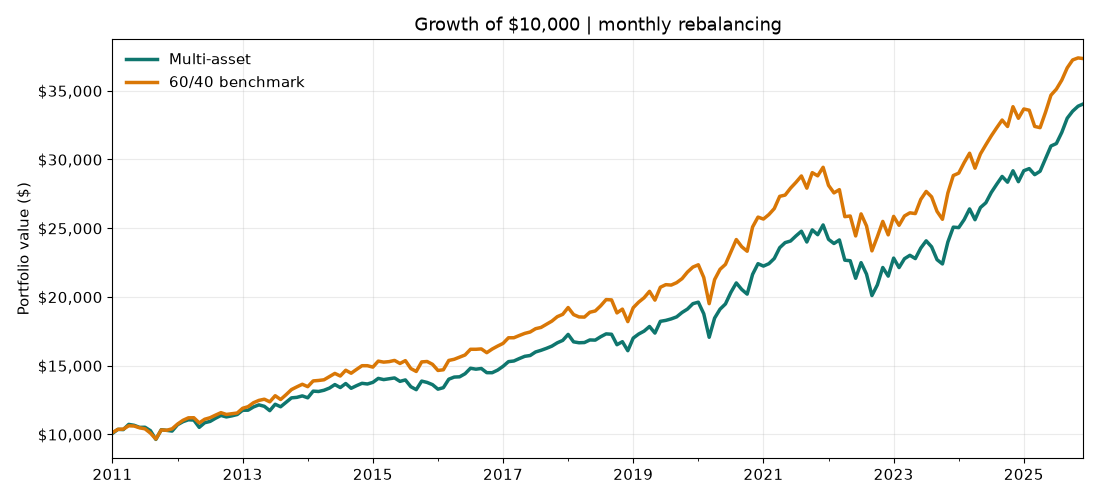

In [1]:
ax = wealth.plot(color=['#0f766e', '#d97706'], linewidth=2.5)
ax.set(title='Growth of $10,000 | monthly rebalancing', xlabel='', ylabel='Portfolio value ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 4. Drawdowns

A drawdown is the percentage decline from the prior peak. This chart shows the depth and duration of difficult periods. It uses month-end data, so intramonth declines are not captured.

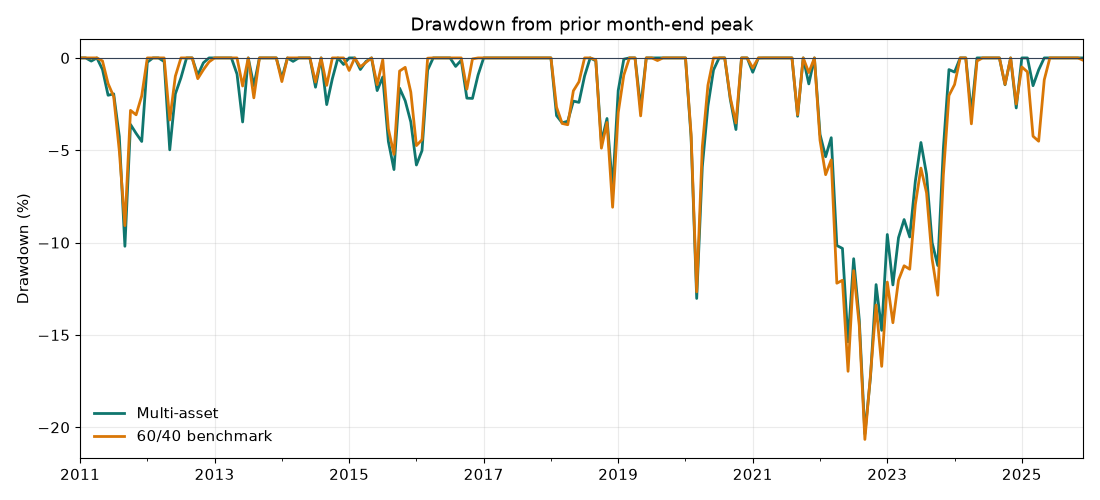

In [2]:
drawdown = wealth.div(wealth.cummax().clip(lower=10000)).sub(1)
ax = drawdown.mul(100).plot(color=['#0f766e', '#d97706'], linewidth=2)
ax.set(title='Drawdown from prior month-end peak', xlabel='', ylabel='Drawdown (%)')
ax.axhline(0, color='#334155', linewidth=.8)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 5. Annual returns and market cycles

Each bar compounds the twelve monthly returns in that year. Look at both strong and weak periods: 2020's shock and recovery, 2021's strong equity market, and the 2022 stock/bond selloff.

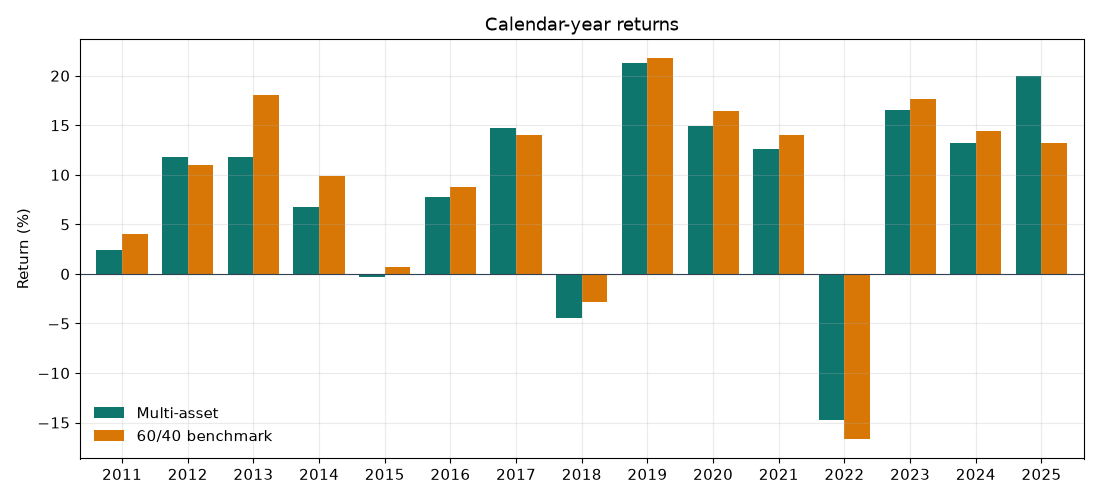

In [3]:
annual = (1 + returns).groupby(returns.index.year).prod().sub(1)
ax = annual.mul(100).plot.bar(color=['#0f766e', '#d97706'], width=.78)
ax.set(title='Calendar-year returns', xlabel='', ylabel='Return (%)')
ax.axhline(0, color='#334155', linewidth=.8)
ax.legend(frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Asset relationships

Correlation measures how monthly ETF returns moved together during this sample. Values near +1 indicate similar movement; values near −1 indicate opposite movement. Correlations can change, especially in stressed markets. Gold and REITs remain risky even if their correlations are lower than those of stocks and bonds.

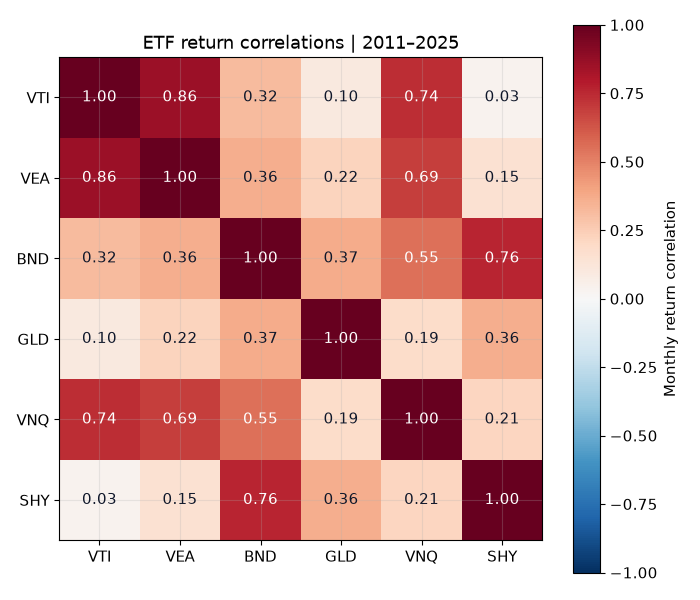

In [4]:
corr = asset_returns.corr()
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(TICKERS)), TICKERS)
ax.set_yticks(range(len(TICKERS)), TICKERS)
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > .55 else '#0f172a')
fig.colorbar(image, ax=ax, label='Monthly return correlation')
ax.set_title('ETF return correlations | 2011–2025')
plt.tight_layout()
plt.show()


## 7. Risk-adjusted summary and interpretation

CAGR is compounded annual growth. Volatility is monthly sample standard deviation × √12. The Sharpe-style ratio below uses a **0% risk-free rate**; it is not an estimate against historical Treasury bill yields. Maximum drawdown uses month-end wealth.

In [ ]:
def summarize(series):
    n = len(series)
    ending = 10000 * (1 + series).prod()
    annualized_return = (ending / 10000) ** (12 / n) - 1
    annualized_vol = series.std() * math.sqrt(12)
    path = 10000 * (1 + series).cumprod()
    return pd.Series({
        'Ending $10,000': ending,
        'CAGR': annualized_return,
        'Volatility': annualized_vol,
        'Sharpe, 0% RF': series.mean() * 12 / annualized_vol,
        'Max drawdown': path.div(path.cummax().clip(lower=10000)).sub(1).min(),
        'Positive months': series.gt(0).mean(),
    })

summary = returns.apply(summarize)
print(summary.to_string(float_format=lambda x: f'{x:,.3f}'))
for name in summary.columns:
    result = summary[name]
    print(f"{name}: CAGR {result['CAGR']:.2%}; volatility {result['Volatility']:.2%}; "
          f"Sharpe (0% RF) {result['Sharpe, 0% RF']:.2f}; "
          f"max drawdown {result['Max drawdown']:.2%}.")

return_gap = summary.loc['CAGR', 'Multi-asset'] - summary.loc['CAGR', '60/40 benchmark']
vol_gap = summary.loc['Volatility', 'Multi-asset'] - summary.loc['Volatility', '60/40 benchmark']
print(f'Multi-asset minus 60/40: CAGR {return_gap:+.2%}; volatility {vol_gap:+.2%}.')
print(f"2022: multi-asset {annual.loc[2022, 'Multi-asset']:.2%}; "
      f"60/40 {annual.loc[2022, '60/40 benchmark']:.2%}.")


### How to interpret the evidence

- **Return:** The growth chart and CAGR show the reward delivered over this specific 15-year period.
- **Risk:** Volatility shows typical variation; maximum drawdown shows the deepest observed month-end loss. Neither captures every possible future loss.
- **Diversification:** The correlation chart describes historical co-movement, while annual and drawdown charts show what that meant in actual market cycles. Lower correlation does not guarantee a smoother total portfolio.
- **Client fit:** For a moderate-risk investor, assess whether the realized return justified the drawdowns and whether the holding mix supports the client's liquidity needs. This backtest alone cannot determine suitability.

**Limitations:** ETF proxies, provider-adjusted prices, monthly observations, fixed weights and the chosen start/end dates shape the findings. Fees, taxes, trading costs, inflation, and cash flows are omitted. This is a hypothetical historical simulation, not a forecast or personalized recommendation.